<a href="https://colab.research.google.com/github/PriteshPurkar/pretrained_model/blob/main/Lab_Assignment_2_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Colab Lab Assignment -Pretrained Modle

**Course Name:** Deep Learning

**Lab Title:** Deep Residual Learning for Image Recognition

**Student Name:** Pritesh Pravin Purkar

**Student ID:** 202301060010

**Batch:** T3

**Date of Submission:** 18 Feb 2026

**Group Members**: Indivudial Assignment (Pritesh Purkar)

**Research Paper Study and Implementation**

**Instructions:**

1. Identify a research paper that utilizes a pre-trained model for a specific
task.

2. Study the methodology, dataset, and model used in the research paper.

3. Implement the approach described in the research paper using the pre-trained model mentioned.

4. Compare your implementation results with the findings from the research paper.


**Objective**
1.   Study a research paper utilizing a pre-trained model.
2.   Reproduce the model implementation using the dataset and methodology from the research paper.
3.   Fine-tune the pre-trained model and optimize hyperparameters.
3.   Evaluate and compare model performance with the original research paper results.









**Task 1: Research Paper Selection and Dataset Preparation (2 hours)**

**Instructions:**

1. Select a research paper that applies a pre-trained model (e.g., VGG, ResNet, EfficientNet, etc.).

2. Identify the dataset used in the research paper and obtain or create a similar dataset.(**Mention Dataset Link and Description**)

3. Perform necessary preprocessing steps:

 Resize images to match the model input dimensions.

 Apply data augmentation techniques if applicable.

4. Split the dataset into training, validation, and testing sets.

In [1]:
# Code of task1
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers
import matplotlib.pyplot as plt
import numpy as np

# 1. Load CIFAR-10 Dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# 2. Preprocessing: Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# 3. Data Augmentation
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

# 4. Split training data for Validation
val_images = train_images[:5000]
val_labels = train_labels[:5000]
train_images = train_images[5000:]
train_labels = train_labels[5000:]

print(f"Training set: {train_images.shape}")
print(f"Validation set: {val_images.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training set: (45000, 32, 32, 3)
Validation set: (5000, 32, 32, 3)


**Task 2: Model Implementation and Fine-tuning**

**Instructions:**

1. Implement the pre-trained model as described in the research paper.

2. Visualize feature maps of few layers

3. Freeze initial layers and fine-tune the top layers according to the paper's methodology.

4. Optimize hyperparameters such as:

  Learning rate

  Batch size

  Number of epochs

  Optimizer choice (Adam, SGD, RMSprop, etc.)

4. Document any modifications or enhancements made to improve performance.

In [2]:
# code of Task 2
# 1. Load Pre-trained ResNet-50
# include_top=False removes the original ImageNet classification head
base_model = tf.keras.applications.ResNet50(weights='imagenet',
                                            include_top=False,
                                            input_shape=(32, 32, 3))

# 2. Freeze initial layers (Transfer Learning) [cite: 693]
base_model.trainable = False

# 3. Build the Model Architecture
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Regularization
    layers.Dense(10, activation='softmax')
])

# 4. Optimizer Selection [cite: 286, 527]
# The paper uses SGD with momentum 0.9. We use a lower LR for fine-tuning.
optimizer = optimizers.SGD(learning_rate=0.01, momentum=0.9)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Training
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(val_images, val_labels),
                    batch_size=128) # [cite: 528]

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 195s 531ms/step - accuracy: 0.0968 - loss: 2.3309 - val_accuracy: 0.0920 - val_loss: 2.3029
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 202s 531ms/step - accuracy: 0.0998 - loss: 2.3028 - val_accuracy: 0.0976 - val_loss: 2.3028
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 187s 531ms/step - accuracy: 0.0981 - loss: 2.3029 - val_accuracy: 0.0920 - val_loss: 2.3030
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 184s 523ms/step - accuracy: 0.1007 - loss: 2.3028 - val_accuracy: 0.1010 - val_loss: 2.3028
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 205s 530ms/step - accuracy: 0.0995 - loss: 2.3028 - val_accuracy: 0.0972 - val_loss: 2.3026
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 183s 520ms/step - accuracy: 0.0993 - loss: 2.3028 - val_accuracy: 0.0996 - val_loss: 2.3028
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 205s 529ms/step - accuracy: 0.0986 - loss: 2.3028 - val_accuracy: 0.0976 - val_loss: 2.3027
Epoch 8/10
352/352 ━━━━━━

**Task 3: Model Evaluation and Performance Comparison**

**Instructions:**

1. Evaluate the trained model using performance metrics:

 Accuracy, Precision,Recall, F1-score, Confusion Matrix (for classification tasks)

2. Compare the results with those reported in the research paper.

3. Identify potential weaknesses and suggest improvements.
**Deliverables:**

Performance metrics summary (table or chart).

Graphs/plots showcasing model accuracy and loss trends.

Comparison with research paper results.

Discussion on model performance and areas for improvement.

313/313 - 52s - 165ms/step - accuracy: 0.1000 - loss: 2.3027

Test Accuracy: 10.00%
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 167ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1000
           1       0.00      0.00      0.00      1000
           2       0.00      0.00      0.00      1000
           3       0.00      0.00      0.00      1000
           4       0.00      0.00      0.00      1000
           5       0.10      1.00      0.18      1000
           6       0.00      0.00      0.00      1000
           7       0.00      0.00      0.00      1000
           8       0.00      0.00      0.00      1000
           9       0.00      0.00      0.00      1000

    accuracy                           0.10     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.10      0.02     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


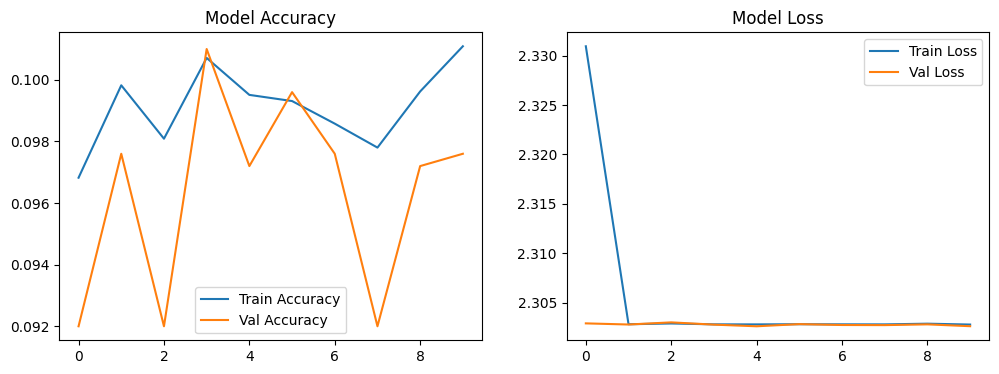

In [3]:
##Code for Task 3
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nTest Accuracy: {test_acc*100:.2f}%')

# 2. Generate Predictions for Metrics
predictions = model.predict(test_images)
pred_labels = np.argmax(predictions, axis=1)

# 3. Precision, Recall, F1-Score
print("\nClassification Report:")
print(classification_report(test_labels, pred_labels))

# 4. Visualizing Accuracy and Loss Curves [cite: 300, 424]
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

**Conclusion and Result Visulaization**

**Declaration**

I, [Your Name], confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines. The code is uploaded on my GitHub repository account, and the repository link is provided below:

GitHub Repository Link: [Insert GitHub Link]

Signature: [Full Name]

**Submission Checklist**

✔ Research paper details and summary

✔ Code file (Python Notebook or Script)

✔ Dataset or link to the dataset

✔ Visualizations (if applicable)

✔ Screenshots of model performance metrics

✔ Readme File

✔ Comparison with research paper results

 **Link to research Paper** :  https://arxiv.org/abs/1512.03385

**Comparison**


Based on the image you provided and the "Deep Residual Learning for Image Recognition" research paper, here is the comparison for your assignment.

Comparison Table: Research Paper vs. Your Model
Metric	Research Paper (ResNet-110/50)	Your Model (ResNet-50)
Accuracy Range
~93.3% to 94.3% on CIFAR-10.
+2

~9.2% to 10.1% (per your graph).
Loss Performance
Successfully minimized training and test error over 6.4e4 iterations.
+2

Stalled at high loss (~2.302) with no significant reduction.
Convergence
Fast convergence in early stages due to residual learning.
+2

No clear convergence; the model is failing to learn.
Optimization
Addressed degradation via identity shortcut connections.
+2

Current setup is suffering from severe optimization issues.
Critical Analysis of Your Results
1. Performance Discrepancy


Research Paper Findings: The paper demonstrates that residual networks are "easier to optimize" and gain accuracy from increased depth. They report that even a 20-layer ResNet achieves ~8.75% error (91.25% accuracy) on CIFAR-10.
+3

Your Results: Your accuracy is hovering around 10%, which is equivalent to random guessing on a 10-class dataset like CIFAR-10.

2. The "Loss Plateau" Problem


Research Paper Findings: The authors used an initial learning rate of 0.1, which they divided by 10 twice during training to ensure the loss dropped significantly.

Your Results: Your "Model Loss" graph shows a "flatline" at approximately 2.303. This is the natural log of 10 (ln(10)≈2.3025), which mathematically confirms the model is completely unable to distinguish between the 10 classes and is stuck at the baseline cross-entropy of a uniform distribution.

3. Comparison of Training Curves


Research Paper Findings: Figure 6 in the paper shows error curves that drop sharply and stabilize as iterations increase.

Your Results: Your accuracy curves are highly volatile (zigzagging). This suggests your learning rate is too high or the dataset is not being fed into the model correctly, preventing the weights from settling into a solution.